In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from catboost import Pool
import shap

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [66]:
train = pd.read_csv("/content/drive/MyDrive/dsn26/processed_train.csv")
test = pd.read_csv("/content/drive/MyDrive/dsn26/processed_test.csv")
y = pd.read_csv("/content/drive/MyDrive/dsn26/target.csv")

In [67]:
n_train = train.shape[0]
n_train

6818

In [68]:
display(train.head())
print("\n\n")
display(test.head())

,id,product_weight_kg,fat_content,shelf_visibility,product_price,store_age_years,store_size,store_location_tier,store_format,price_vs_cat,price_rank_in_cat,price_vs_store,price_per_kg,weight_vs_cat,vis_vs_product,vis_x_price
0,row_00000,14.252000,20,0.0271,81.37,45,30,30,20,0.630238,0.234813,0.575641,5.709374,1.115616,0.409863,2.205127
1,row_00001,7.698000,20,0.0720,42.05,35,10,10,20,0.326007,0.086538,0.295775,5.462458,0.638414,1.088934,3.027600
2,row_00002,14.264000,10,0.0421,41.35,33,20,10,20,0.298018,0.023112,0.294545,2.898906,1.155650,0.636724,1.740835
3,row_00003,12.899667,10,0.0449,174.35,47,20,30,40,1.214306,0.732584,1.247467,13.515853,1.091619,0.679071,7.828315
4,row_00004,10.338000,10,0.0120,203.06,28,10,20,20,1.384185,0.868235,1.419477,19.642097,0.838375,0.181489,2.436720


,id,product_weight_kg,fat_content,shelf_visibility,product_price,store_age_years,store_size,store_location_tier,store_format,price_vs_cat,price_rank_in_cat,price_vs_store,price_per_kg,weight_vs_cat,vis_vs_product,vis_x_price
0,row_00009,8.628000,20,0.0167,190.72,23,20,30,30,1.244705,0.748352,1.345452,22.104775,0.643209,0.252572,3.185024
1,row_00015,6.993000,20,0.0579,261.07,28,10,20,20,2.024034,0.982692,1.824992,37.333047,0.579947,0.875684,15.115953
2,row_00019,17.167667,20,0.1262,112.50,47,20,30,40,0.782337,0.328328,0.804933,6.553016,1.307324,1.908659,14.197500
3,row_00020,14.034000,10,0.0761,200.71,30,10,20,20,1.554566,0.802570,1.424928,14.301696,1.098552,1.150943,15.274031
4,row_00023,13.063000,20,0.0650,150.59,33,20,10,20,1.166370,0.586449,1.072687,11.527980,1.022544,0.983065,9.788350


In [69]:
test_id = test['id']

In [70]:
train.drop("id", axis=1, inplace=True, errors = "ignore")
test.drop("id", axis=1, inplace=True, errors = "ignore")

In [71]:
categorical_cols = ["fat_content", "store_size", "store_location_tier", "store_format"]

for col in categorical_cols:
    if col in train.columns and train[col].dtype == 'int64':
        train[col] = train[col].astype('category')

for col in categorical_cols:
    if col in test.columns and test[col].dtype == 'int64':
        test[col] = test[col].astype('category')

In [72]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   product_weight_kg    6818 non-null   float64 
 1   fat_content          6818 non-null   category
 2   shelf_visibility     6818 non-null   float64 
 3   product_price        6818 non-null   float64 
 4   store_age_years      6818 non-null   int64   
 5   store_size           6818 non-null   category
 6   store_location_tier  6818 non-null   category
 7   store_format         6818 non-null   category
 8   price_vs_cat         6818 non-null   float64 
 9   price_rank_in_cat    6818 non-null   float64 
 10  price_vs_store       6818 non-null   float64 
 11  price_per_kg         6818 non-null   float64 
 12  weight_vs_cat        6818 non-null   float64 
 13  vis_vs_product       6818 non-null   float64 
 14  vis_x_price          6818 non-null   float64 
dtypes: category(4), float

## Train Base Model

In [73]:
cbr = CatBoostRegressor(loss_function = "RMSE",
                        cat_features =categorical_cols
                        )

In [74]:
cbr.fit(train, y)

Learning rate set to 0.055449
0:	learn: 1646.7156893	total: 10.9ms	remaining: 10.9s
1:	learn: 1599.6804426	total: 19.4ms	remaining: 9.66s
2:	learn: 1555.8543048	total: 27.5ms	remaining: 9.14s
3:	learn: 1515.1217493	total: 35.6ms	remaining: 8.87s
4:	learn: 1478.5418159	total: 43.2ms	remaining: 8.61s
5:	learn: 1443.1478440	total: 50.9ms	remaining: 8.44s
6:	learn: 1411.7515069	total: 57.9ms	remaining: 8.21s
7:	learn: 1382.1982407	total: 65.2ms	remaining: 8.08s
8:	learn: 1355.0230240	total: 73.1ms	remaining: 8.05s
9:	learn: 1330.5964813	total: 80.4ms	remaining: 7.96s
10:	learn: 1307.9452983	total: 87.7ms	remaining: 7.88s
11:	learn: 1287.6570821	total: 95.4ms	remaining: 7.85s
12:	learn: 1268.4257361	total: 102ms	remaining: 7.78s
13:	learn: 1250.5041734	total: 112ms	remaining: 7.89s
14:	learn: 1234.5775871	total: 120ms	remaining: 7.87s
15:	learn: 1220.5688253	total: 127ms	remaining: 7.83s
16:	learn: 1207.0441847	total: 134ms	remaining: 7.78s
17:	learn: 1195.1163238	total: 142ms	remaining: 7.

CatBoostRegressor(cat_features=['fat_content', 'store_size', 'store_location_tier', 'store_format'], loss_function='RMSE')

In [75]:
cbr.score(train, y)

np.float64(0.7536550080777428)

In [76]:
importance = cbr.get_feature_importance(type='PredictionValuesChange')

fi_df = pd.DataFrame({'feature': train.columns, 'importance': importance }).sort_values('importance', ascending=False)

print(fi_df)

                feature  importance
7          store_format   30.978190
10       price_vs_store   11.481977
3         product_price   10.102345
8          price_vs_cat    8.676572
9     price_rank_in_cat    8.653130
4       store_age_years    5.520410
14          vis_x_price    4.522503
11         price_per_kg    4.169568
0     product_weight_kg    4.017208
12        weight_vs_cat    2.849695
2      shelf_visibility    2.496769
5            store_size    2.122139
6   store_location_tier    1.867449
13       vis_vs_product    1.824622
1           fat_content    0.717422


In [77]:
pool = Pool(train, y, cat_features=categorical_cols)
importance = cbr.get_feature_importance(pool,type='LossFunctionChange')

fi_df = pd.DataFrame({'feature': train.columns,'importance': importance}).sort_values('importance', ascending=False)

print(fi_df)

                feature  importance
7          store_format  297.581691
10       price_vs_store   93.089356
3         product_price   76.551173
9     price_rank_in_cat   35.867202
8          price_vs_cat   28.335120
14          vis_x_price   24.724109
11         price_per_kg   21.090927
0     product_weight_kg   19.491045
4       store_age_years   13.893613
12        weight_vs_cat   13.655938
2      shelf_visibility   10.646444
13       vis_vs_product    9.256688
5            store_size    5.832500
6   store_location_tier    5.439341
1           fat_content    2.556907


In [78]:
cbr.score(train, y)

np.float64(0.7536550080777428)

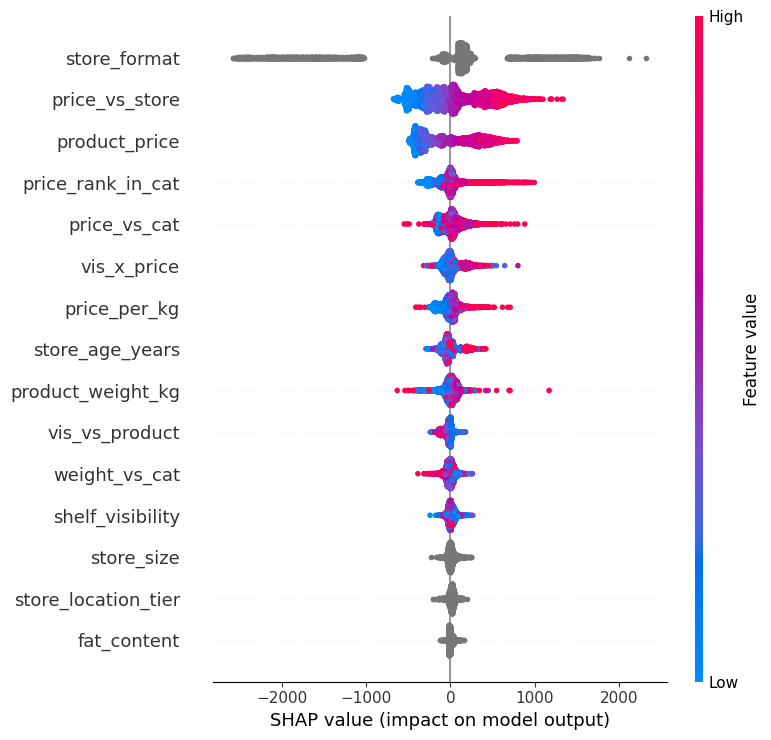

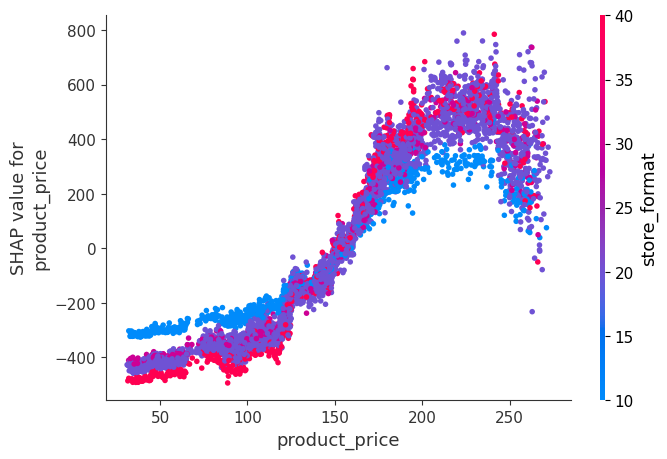

In [79]:
data_pool = Pool(data=train, label=y, cat_features=categorical_cols)

shap_values = cbr.get_feature_importance(data=data_pool, type='ShapValues')
shap_values_core = shap_values[:, :-1]

shap.initjs()
X_sample = train

shap.summary_plot(shap_values_core, X_sample)

shap.dependence_plot('product_price', shap_values_core, X_sample)

In [80]:
importance = cbr.get_feature_importance(type='PredictionValuesChange')

fi_df = pd.DataFrame({'feature': train.columns, 'importance': importance }).sort_values('importance', ascending=False)

print(fi_df)

                feature  importance
7          store_format   30.978190
10       price_vs_store   11.481977
3         product_price   10.102345
8          price_vs_cat    8.676572
9     price_rank_in_cat    8.653130
4       store_age_years    5.520410
14          vis_x_price    4.522503
11         price_per_kg    4.169568
0     product_weight_kg    4.017208
12        weight_vs_cat    2.849695
2      shelf_visibility    2.496769
5            store_size    2.122139
6   store_location_tier    1.867449
13       vis_vs_product    1.824622
1           fat_content    0.717422


In [81]:
fi_df[fi_df["importance"] >10]['feature'].tolist()

['store_format', 'price_vs_store', 'product_price']

In [84]:
train = train[fi_df[fi_df["importance"] >10]['feature'].tolist()]
test = test[fi_df[fi_df["importance"] >10]['feature'].tolist()]

In [85]:
train.head()

,store_format,price_vs_store,product_price
0,20,0.575641,81.37
1,20,0.295775,42.05
2,20,0.294545,41.35
3,40,1.247467,174.35
4,20,1.419477,203.06


In [86]:
categorical_cols = ["store_format"]

In [87]:
cbr = CatBoostRegressor(loss_function = "RMSE",
                        cat_features =categorical_cols
                        )

cbr.fit(train,y)

Learning rate set to 0.055449
0:	learn: 1645.8301061	total: 7.82ms	remaining: 7.81s
1:	learn: 1597.8899821	total: 12.6ms	remaining: 6.29s
2:	learn: 1554.1370250	total: 18ms	remaining: 5.97s
3:	learn: 1513.4690144	total: 22.7ms	remaining: 5.64s
4:	learn: 1474.9271445	total: 27.4ms	remaining: 5.46s
5:	learn: 1439.9644774	total: 32ms	remaining: 5.31s
6:	learn: 1407.6271641	total: 36.6ms	remaining: 5.19s
7:	learn: 1377.3963201	total: 41.2ms	remaining: 5.11s
8:	learn: 1351.1963353	total: 45.3ms	remaining: 4.99s
9:	learn: 1329.1852969	total: 49.5ms	remaining: 4.9s
10:	learn: 1306.4483108	total: 54.1ms	remaining: 4.87s
11:	learn: 1286.6517930	total: 58.6ms	remaining: 4.82s
12:	learn: 1268.1867391	total: 63ms	remaining: 4.78s
13:	learn: 1250.4849873	total: 67.5ms	remaining: 4.75s
14:	learn: 1234.3246755	total: 71.5ms	remaining: 4.69s
15:	learn: 1219.7405718	total: 75.7ms	remaining: 4.65s
16:	learn: 1205.7527562	total: 80.2ms	remaining: 4.64s
17:	learn: 1193.1822606	total: 84.8ms	remaining: 4.6

CatBoostRegressor(cat_features=['store_format'], loss_function='RMSE')

In [88]:
cbr.score(train, y)

np.float64(0.6464981292165308)

In [89]:
importance = cbr.get_feature_importance(type='PredictionValuesChange')

fi_df = pd.DataFrame({'feature': train.columns, 'importance': importance }).sort_values('importance', ascending=False)

print(fi_df)

          feature  importance
0    store_format   51.591944
1  price_vs_store   26.257105
2   product_price   22.150952


## Hyperparameter Tuning

In [92]:
cb_param_distributions = {
    'iterations': range(800, 1000, 50),
    'learning_rate': [0.01, 0.02, 0.03],
    'depth': range(2,5,1),
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'subsample': [0.6,],
    'colsample_bylevel': [0.8]
}


cat_model = CatBoostRegressor(random_seed=42, loss_function='RMSE', verbose=0, )

random_search_cb = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cb_param_distributions,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_cb.fit(train, y, cat_features = categorical_cols)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bylevel': [0.8],
                                        'depth': range(2, 5),
                                        'iterations': range(800, 1000, 50),
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.02, 0.03],
                                        'subsample': [0.6]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [93]:
random_search_cb.best_params_

{'subsample': 0.6,
 'learning_rate': 0.01,
 'l2_leaf_reg': 5,
 'iterations': 800,
 'depth': 4,
 'colsample_bylevel': 0.8}

In [94]:
random_search_cb.best_score_

np.float64(-1074.9366805706522)

In [95]:
cbr = CatBoostRegressor(loss_function = "RMSE",
                        cat_features =categorical_cols,
                        **random_search_cb.best_params_)

In [96]:
cbr.fit(train, y)

0:	learn: 1689.5079484	total: 2.83ms	remaining: 2.26s
1:	learn: 1680.4846824	total: 6.32ms	remaining: 2.52s
2:	learn: 1671.6711580	total: 8.11ms	remaining: 2.15s
3:	learn: 1663.7339929	total: 9.6ms	remaining: 1.91s
4:	learn: 1655.3297618	total: 11.3ms	remaining: 1.79s
5:	learn: 1646.8490583	total: 12.9ms	remaining: 1.7s
6:	learn: 1639.2226177	total: 14.7ms	remaining: 1.66s
7:	learn: 1631.6668625	total: 16.5ms	remaining: 1.63s
8:	learn: 1623.5124968	total: 18.1ms	remaining: 1.59s
9:	learn: 1615.4458577	total: 19.7ms	remaining: 1.56s
10:	learn: 1608.3756440	total: 21.5ms	remaining: 1.54s
11:	learn: 1600.6483921	total: 23.3ms	remaining: 1.53s
12:	learn: 1592.8928120	total: 25ms	remaining: 1.51s
13:	learn: 1585.3720006	total: 26.8ms	remaining: 1.5s
14:	learn: 1577.8526807	total: 28.5ms	remaining: 1.49s
15:	learn: 1570.4896986	total: 30.1ms	remaining: 1.48s
16:	learn: 1563.2382954	total: 31.9ms	remaining: 1.47s
17:	learn: 1556.0065900	total: 33.5ms	remaining: 1.45s
18:	learn: 1549.5349962	t

CatBoostRegressor(cat_features=['store_format'], colsample_bylevel=0.8, depth=4, iterations=800, l2_leaf_reg=5, learning_rate=0.01, loss_function='RMSE', subsample=0.6)

In [97]:
cbr.score(train, y)

np.float64(0.6048413019842303)

In [99]:
pd.DataFrame({"id": test_id, "total_sales": cbr.predict(test)}).to_csv("submission.csv", index=False)